In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.model_selection as train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [2]:
selected_sensors = [
    "sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_8", "sensor_9", "sensor_11", "sensor_12", "sensor_13", "sensor_14", "sensor_15", "sensor_17", "sensor_20"
]

In [3]:
train = pd.read_csv("../data/processed/train_FD001_processed.csv")
model_data = train[["engine_id", "cycle"] + selected_sensors + ["RUL"]].copy()
model_data.to_csv("../data/processed/FD001_selected_features.csv", index=False)

In [4]:
engine_ids = model_data["engine_id"].unique()
train_engines, val_engines = train_test_split.train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_data = model_data[model_data["engine_id"].isin(train_engines)].copy()
val_data = model_data[model_data["engine_id"].isin(val_engines)].copy()

In [5]:
print("Training engines:", len(train_engines))
print("Validation engines:", len(val_engines))

print("Training rows:", len(train_data))
print("Validation rows:", len(val_data))

Training engines: 80
Validation engines: 20
Training rows: 16561
Validation rows: 4070


In [6]:
features = ["cycle"] + selected_sensors

X_train = train_data[features]
y_train = train_data["RUL"]

X_val = val_data[features]
y_val = val_data["RUL"]


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [8]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)

In [9]:
train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)

train_rmse = root_mean_squared_error(y_train, y_train_pred)
val_rmse = root_mean_squared_error(y_val, y_val_pred)

In [10]:
print("Training MAE:", train_mae)
print("Validation MAE:", val_mae)

print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

Training MAE: 32.54387340997973
Validation MAE: 25.1301073686816
Training RMSE: 42.3764218979544
Validation RMSE: 31.642480146853828


Linear regression (baseline) -> DONE

In [11]:
results = val_data.copy()

results["predicted_RUL"] = y_val_pred

results["error"] = (
    results["predicted_RUL"]
    - results["RUL"]
)

results["absolute_error"] = abs(results["error"])
results.sort_values(
    "absolute_error",
    ascending=False
).head(20)

,engine_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,RUL,predicted_RUL,error,absolute_error
16885,84,1,643.21,1582.28,1411.05,552.34,2388.13,9047.16,47.70,521.74,2388.17,8126.26,8.4379,393,38.69,266,144.241686,-121.758314,121.758314
16895,84,11,642.52,1591.73,1414.97,553.17,2388.13,9050.57,47.68,521.04,2388.16,8127.50,8.4334,394,38.77,256,139.886024,-116.113976,116.113976
16886,84,2,643.03,1590.29,1405.09,552.78,2388.11,9049.45,47.59,521.42,2388.21,8130.41,8.4355,391,38.86,265,151.167171,-113.832829,113.832829
16891,84,7,643.18,1592.68,1406.51,553.42,2388.09,9052.31,47.65,521.54,2388.13,8124.68,8.4577,393,38.79,260,147.027700,-112.972300,112.972300
16896,84,12,643.19,1583.14,1402.03,553.06,2388.10,9041.66,47.71,521.02,2388.10,8133.01,8.4633,394,38.75,255,142.106696,-112.893304,112.893304
16888,84,4,642.81,1583.83,1410.99,552.91,2388.16,9047.11,47.54,521.02,2388.15,8125.17,8.4267,392,38.80,263,150.662511,-112.337489,112.337489
16897,84,13,642.43,1593.97,1413.78,552.66,2388.12,9048.77,47.69,521.63,2388.11,8127.55,8.4428,393,38.89,254,143.133881,-110.866119,110.866119
16889,84,5,643.05,1590.42,1409.12,553.06,2388.09,9040.72,47.46,521.10,2388.14,8133.34,8.4131,395,38.88,262,151.546440,-110.453560,110.453560
16894,84,10,642.51,1588.42,1411.19,553.00,2388.15,9041.87,47.49,520.81,2388.10,8127.63,8.4668,392,38.90,257,148.238469,-108.761531,108.761531
16903,84,19,642.85,1589.71,1411.99,553.04,2388.10,9045.48,47.72,521.07,2388.16,8128.78,8.4318,393,38.92,248,139.483132,-108.516868,108.516868


In [12]:
engine_errors = (
    results
    .groupby("engine_id")["absolute_error"]
    .mean()
    .sort_values(ascending=False)
)

engine_errors

engine_id
45    51.909716
84    51.233663
74    41.877895
77    34.855505
91    34.115766
1     27.064463
13    26.024177
19    25.131687
5     24.819508
23    24.368476
81    22.662805
54    19.911998
46    18.301400
78    17.881870
31    17.569992
11    17.416453
34    16.273180
71    15.996809
32    13.569063
40    13.499361
Name: absolute_error, dtype: float64

Analysis:
- most of the wrong predictions are much lower than the actual values
- the first cycles are the cycles with the largest errors
- why is there huge difference in prediction error between engine 45 and 40 (51 ->> 13)? 

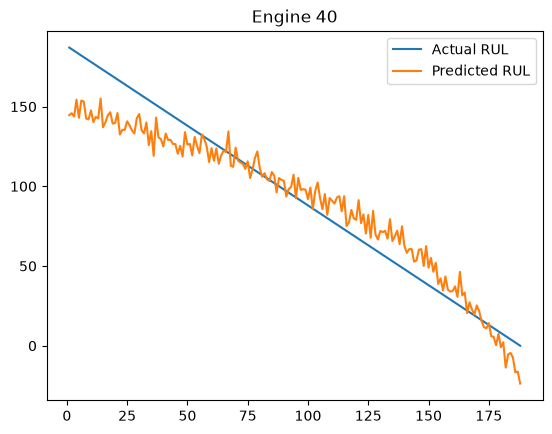

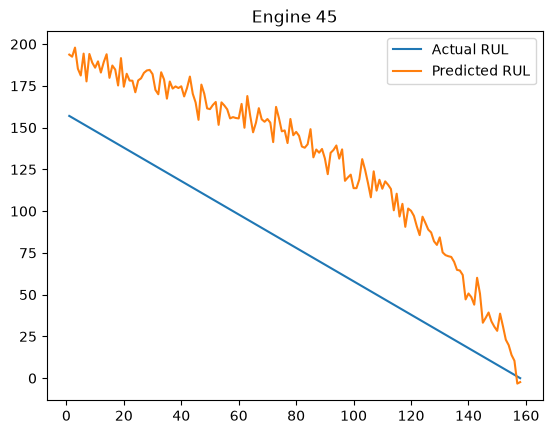

In [13]:
engine_40 = results[results["engine_id"] == 40]
engine_45 = results[results["engine_id"] == 45]

plt.plot(
    engine_40["cycle"],
    engine_40["RUL"],
    label="Actual RUL"
)

plt.plot(
    engine_40["cycle"],
    engine_40["predicted_RUL"],
    label="Predicted RUL"
)

plt.legend()
plt.title("Engine 40")
plt.show()
plt.plot(
    engine_45["cycle"],
    engine_45["RUL"],
    label="Actual RUL"
)

plt.plot(
    engine_45["cycle"],
    engine_45["predicted_RUL"],
    label="Predicted RUL"
)

plt.legend()
plt.title("Engine 45")
plt.show()


deduction from comparison between 40 and 45:
- engine 40 starts by underestimating RUL, then near the end it starts overestimating
- while engine 45 predicts that it has much more RUL than it actually does
- so the model predicts engine 45 is much more healthier than it actually is.
- it looks like early life is difficult to predict
- different engines have VERY different error patterns
- also, why is the model predicting RUL < 0 near the end? which isnt possible
- now, why is that so...

corrected error analysis: 
- Large errors occur especially during early/mid engine life, but their direction varies by engine. Some long-lived engines are underpredicted, while some shorter-lived engines are overpredicted.

Lets see if there is a similar error pattern between engine 45 and 84 (worst error engines) 

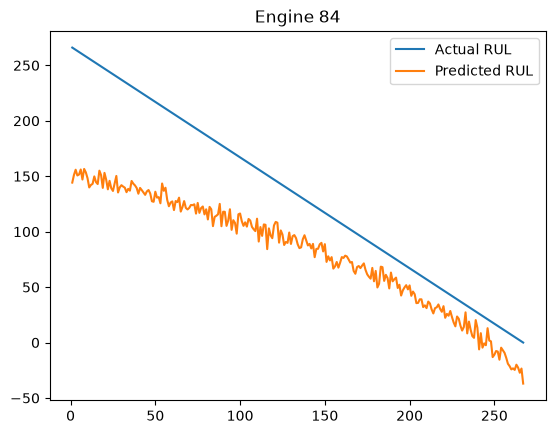

In [14]:
engine_84 = results[results["engine_id"] == 84]
plt.plot(
    engine_84["cycle"],
    engine_84["RUL"],
    label="Actual RUL"
)

plt.plot(
    engine_84["cycle"],
    engine_84["predicted_RUL"],
    label="Predicted RUL"
)

plt.legend()
plt.title("Engine 84")
plt.show()

Deduction from engine 45 vs 84:
- Again, early life is absurd, very difficult to predict
- its close to the actual results near the end
- but here it UNDERestimates the whole prediction , correction to the first conclusion

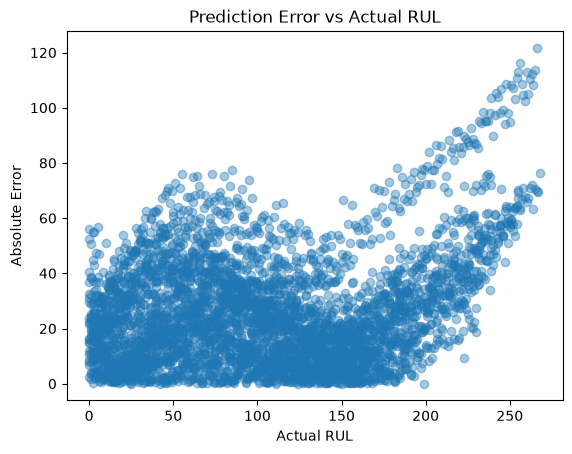

In [15]:
plt.scatter(results["RUL"], results["absolute_error"], alpha=0.4)
plt.xlabel("Actual RUL")
plt.ylabel("Absolute Error")
plt.title("Prediction Error vs Actual RUL")
plt.show()

Analysis:
- At higher RUL, the abs error is much more higher
- So it means at early stages the error is very high

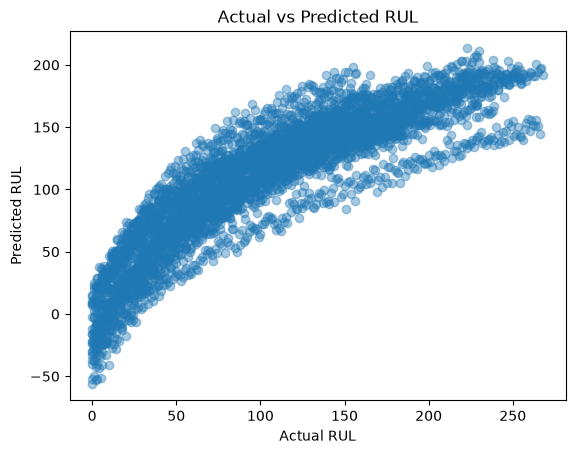

In [16]:
plt.scatter(y_val, y_val_pred, alpha=0.4)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

We'll try capping the RUL from 0 -> 125 since at high RUL the model fails absurdly to predict

In [17]:
RUL_CAP = 125

train_data["RUL_capped"] = train_data["RUL"].clip(upper=RUL_CAP)
val_data["RUL_capped"] = val_data["RUL"].clip(upper=RUL_CAP)

y_train_capped = train_data["RUL_capped"]
y_val_capped = val_data["RUL_capped"]

In [18]:
from sklearn.linear_model import LinearRegression

capped_model = LinearRegression()

capped_model.fit(
    X_train_scaled,
    y_train_capped
)
y_train_capped_pred = capped_model.predict(X_train_scaled)
y_val_capped_pred = capped_model.predict(X_val_scaled)

In [19]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

train_mae = mean_absolute_error(
    y_train_capped,
    y_train_capped_pred
)

val_mae = mean_absolute_error(
    y_val_capped,
    y_val_capped_pred
)

train_rmse = root_mean_squared_error(
    y_train_capped,
    y_train_capped_pred
)

val_rmse = root_mean_squared_error(
    y_val_capped,
    y_val_capped_pred
)

print("Training MAE:", train_mae)
print("Validation MAE:", val_mae)

print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

Training MAE: 16.729504486773738
Validation MAE: 14.520544147609918
Training RMSE: 20.51254638232996
Validation RMSE: 17.920936712251958


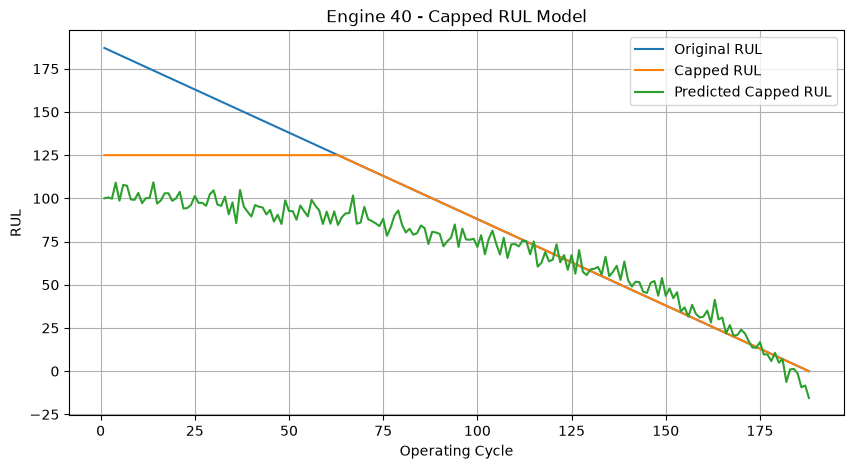

In [20]:
capped_results = val_data.copy()

capped_results["predicted_RUL"] = y_val_capped_pred
engine = capped_results[
    capped_results["engine_id"] == 40
]
plt.figure(figsize=(10, 5))

plt.plot(
    engine["cycle"],
    engine["RUL"],
    label="Original RUL"
)

plt.plot(
    engine["cycle"],
    engine["RUL_capped"],
    label="Capped RUL"
)

plt.plot(
    engine["cycle"],
    engine["predicted_RUL"],
    label="Predicted Capped RUL"
)

plt.xlabel("Operating Cycle")
plt.ylabel("RUL")
plt.title("Engine 40 - Capped RUL Model")
plt.legend()
plt.grid()

plt.show()

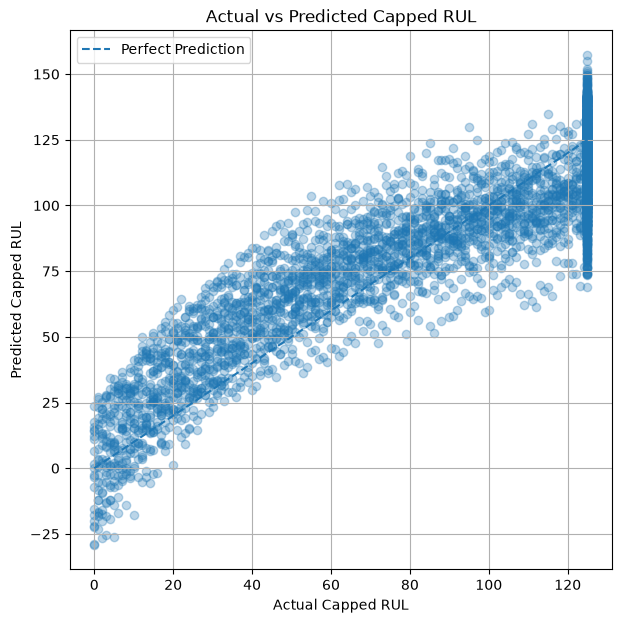

In [21]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_val_capped,
    y_val_capped_pred,
    alpha=0.3
)

plt.plot(
    [0, 125],
    [0, 125],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Capped RUL")
plt.ylabel("Predicted Capped RUL")
plt.title("Actual vs Predicted Capped RUL")

plt.legend()
plt.grid()
plt.show()

Summary:
- the relationship between RUL and sensors is not purely linear
- the model still fails to predict early stages
- once degradation is underway, predictions track RUL better
- negative RUL predictions still occur near failure

We'll try now adding new features before moving on to a new model
- lets begin with rolling average

In [22]:
train_data = train_data.sort_values(
    ["engine_id", "cycle"]
).copy()

val_data = val_data.sort_values(
    ["engine_id", "cycle"]
).copy()

for sensor in selected_sensors:

    # 5-cycle rolling average
    train_data[f"{sensor}_roll5"] = (
        train_data
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                window=5,
                min_periods=1
            ).mean()
        )
    )

    val_data[f"{sensor}_roll5"] = (
        val_data
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                window=5,
                min_periods=1
            ).mean()
        )
    )

    # Change compared with 5 cycles ago
    train_data[f"{sensor}_change5"] = (
        train_data
        .groupby("engine_id")[sensor]
        .diff(5)
        .fillna(0)
    )

    val_data[f"{sensor}_change5"] = (
        val_data
        .groupby("engine_id")[sensor]
        .diff(5)
        .fillna(0)
    )

now add "Change over the last 5 cycles"

In [23]:
features_new = (
    ["cycle"]
    + selected_sensors
    + [f"{sensor}_roll5" for sensor in selected_sensors]
    + [f"{sensor}_change5" for sensor in selected_sensors]
)

now lets test and check MAE

In [24]:
X_train_new = train_data[features_new]
X_val_new = val_data[features_new]

y_train_new = train_data["RUL_capped"]
y_val_new = val_data["RUL_capped"]

In [25]:
scaler_new = StandardScaler()

X_train_new_scaled = scaler_new.fit_transform(X_train_new)
X_val_new_scaled = scaler_new.transform(X_val_new)

model_new = LinearRegression()

model_new.fit(
    X_train_new_scaled,
    y_train_new
)

y_train_new_pred = model_new.predict(
    X_train_new_scaled
)

y_val_new_pred = model_new.predict(
    X_val_new_scaled
)
train_mae_new = mean_absolute_error(
    y_train_new,
    y_train_new_pred
)

val_mae_new = mean_absolute_error(
    y_val_new,
    y_val_new_pred
)

train_rmse_new = root_mean_squared_error(
    y_train_new,
    y_train_new_pred
)

val_rmse_new = root_mean_squared_error(
    y_val_new,
    y_val_new_pred
)

In [26]:
print("Training MAE:", train_mae_new)
print("Validation MAE:", val_mae_new)

print("Training RMSE:", train_rmse_new)
print("Validation RMSE:", val_rmse_new)

Training MAE: 16.54305543277053
Validation MAE: 14.360121990518463
Training RMSE: 20.222223275515706
Validation RMSE: 17.69070398345409


summary:
adding recent history to sensors helped but only very slightly.
so the lack of temporal features wasn't the problem, but probably the linear regression limitation is the actual problem, since the relationship seems Non-linear between sensors and RUL.

NOW, let's move to a new model -> DECISION TREE 

In [27]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)
tree_model.fit(
    X_train_new,
    y_train_new
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [28]:
y_train_tree_pred = tree_model.predict(X_train_new)
y_val_tree_pred = tree_model.predict(X_val_new)
train_mae_tree = mean_absolute_error(
    y_train_new,
    y_train_tree_pred
)

val_mae_tree = mean_absolute_error(
    y_val_new,
    y_val_tree_pred
)

train_rmse_tree = root_mean_squared_error(
    y_train_new,
    y_train_tree_pred
)

val_rmse_tree = root_mean_squared_error(
    y_val_new,
    y_val_tree_pred
)

print("Training MAE:", train_mae_tree)
print("Validation MAE:", val_mae_tree)

print("Training RMSE:", train_rmse_tree)
print("Validation RMSE:", val_rmse_tree)

Training MAE: 0.0
Validation MAE: 13.50958230958231
Training RMSE: 0.0
Validation RMSE: 21.962700119980617


In [29]:
print("Tree depth:", tree_model.get_depth())
print("Number of leaves:", tree_model.get_n_leaves())

Tree depth: 29
Number of leaves: 8867


SUMMARY FOR DECISION TREES:
- textbook definition of overfitted. lets fix that.
- this is most probably because of high variance.
- lets try a random forest

In [30]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [31]:
rf_model.fit(
    X_train_new,
    y_train_new
)
y_train_rf_pred = rf_model.predict(X_train_new)
y_val_rf_pred = rf_model.predict(X_val_new)
train_mae_rf = mean_absolute_error(
    y_train_new,
    y_train_rf_pred
)

val_mae_rf = mean_absolute_error(
    y_val_new,
    y_val_rf_pred
)

train_rmse_rf = root_mean_squared_error(
    y_train_new,
    y_train_rf_pred
)

val_rmse_rf = root_mean_squared_error(
    y_val_new,
    y_val_rf_pred
)

print("Training MAE:", train_mae_rf)
print("Validation MAE:", val_mae_rf)

print("Training RMSE:", train_rmse_rf)
print("Validation RMSE:", val_rmse_rf)

Training MAE: 3.0120342974458065
Validation MAE: 10.091732186732186
Training RMSE: 4.651709629340154
Validation RMSE: 15.370469688727422


summary on random forest:
- still overfitted but much less than a single unstable decision tree
- theres still a gap between train and cross val mae
- this was a default forest, lets play a bit with the params and the features. but in summary random forest could be the best model
- lets start by checking feature importance, as we have many features lets remove and add some. random forest helps us deduce that

In [32]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": features_new,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

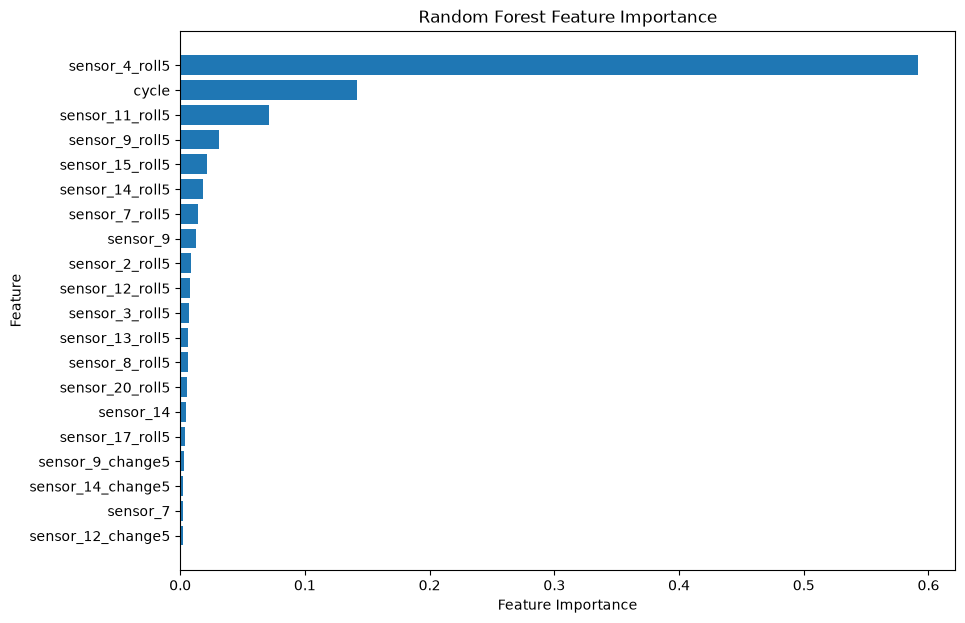

In [33]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

it appears we have many unuseful features, so lets try the top 10 features and check the MAE

In [34]:
top_10_features = (
    feature_importance
    .head(10)["feature"]
    .tolist()
)

In [35]:
X_train_top10 = train_data[top_10_features]
X_val_top10 = val_data[top_10_features]
y_train_top10 = train_data["RUL_capped"]
y_val_top10 = val_data["RUL_capped"]

In [36]:
rf_top10 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_top10.fit(
    X_train_top10,
    y_train_top10
)
y_train_top10_pred = rf_top10.predict(X_train_top10)
y_val_top10_pred = rf_top10.predict(X_val_top10)

train_mae_top10 = mean_absolute_error(
    y_train_top10,
    y_train_top10_pred
)

val_mae_top10 = mean_absolute_error(
    y_val_top10,
    y_val_top10_pred
)

train_rmse_top10 = root_mean_squared_error(
    y_train_top10,
    y_train_top10_pred
)

val_rmse_top10 = root_mean_squared_error(
    y_val_top10,
    y_val_top10_pred
)

print("Training MAE:", train_mae_top10)
print("Validation MAE:", val_mae_top10)

print("Training RMSE:", train_rmse_top10)
print("Validation RMSE:", val_rmse_top10)

Training MAE: 2.534320995108991
Validation MAE: 10.258995085995085
Training RMSE: 4.048530528283035
Validation RMSE: 15.801658716931847


lets start experimenting useful features:
- EXP A: add roll10

In [37]:
for sensor in selected_sensors:

    train_data[f"{sensor}_roll10"] = (
        train_data
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                window=10,
                min_periods=1
            ).mean()
        )
    )

    val_data[f"{sensor}_roll10"] = (
        val_data
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                window=10,
                min_periods=1
            ).mean()
        )
    )
    features_new = (
    ["cycle"]
    + selected_sensors
    + [f"{sensor}_roll5" for sensor in selected_sensors]
    + [f"{sensor}_change5" for sensor in selected_sensors]
)
features_roll10 = (
    features_new
    + [f"{sensor}_roll10" for sensor in selected_sensors]
)

In [38]:
X_train_roll10 = train_data[features_roll10]
X_val_roll10 = val_data[features_roll10]

y_train_roll10 = train_data["RUL_capped"]
y_val_roll10 = val_data["RUL_capped"]

In [39]:
rf_roll10 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_roll10.fit(
    X_train_roll10,
    y_train_roll10
)
y_train_roll10_pred = rf_roll10.predict(X_train_roll10)
y_val_roll10_pred = rf_roll10.predict(X_val_roll10)

train_mae_roll10 = mean_absolute_error(
    y_train_roll10,
    y_train_roll10_pred
)

val_mae_roll10 = mean_absolute_error(
    y_val_roll10,
    y_val_roll10_pred
)

train_rmse_roll10 = root_mean_squared_error(
    y_train_roll10,
    y_train_roll10_pred
)

val_rmse_roll10 = root_mean_squared_error(
    y_val_roll10,
    y_val_roll10_pred
)

print("Training MAE:", train_mae_roll10)
print("Validation MAE:", val_mae_roll10)

print("Training RMSE:", train_rmse_roll10)
print("Validation RMSE:", val_rmse_roll10)

Training MAE: 2.2676565424793185
Validation MAE: 10.012520884520884
Training RMSE: 3.6101238688121744
Validation RMSE: 15.23513085074467


lets try different depths for the trees.

In [40]:
depths = [5, 8, 10, 15, 20, None]

for depth in depths:

    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(
        X_train_roll10,
        y_train_roll10
    )

    train_pred = rf.predict(X_train_roll10)
    val_pred = rf.predict(X_val_roll10)

    train_mae = mean_absolute_error(
        y_train_roll10,
        train_pred
    )

    val_mae = mean_absolute_error(
        y_val_roll10,
        val_pred
    )

    train_rmse = root_mean_squared_error(
        y_train_roll10,
        train_pred
    )

    val_rmse = root_mean_squared_error(
        y_val_roll10,
        val_pred
    )

    print("Max Depth:", depth)
    print("Train MAE:", train_mae)
    print("Val MAE:", val_mae)
    print("Train RMSE:", train_rmse)
    print("Val RMSE:", val_rmse)
    print("-------------------------")

Max Depth: 5
Train MAE: 10.914802597507132
Val MAE: 10.129117033852932
Train RMSE: 15.803969869989569
Val RMSE: 14.781372950368713
-------------------------
Max Depth: 8
Train MAE: 8.368346102874774
Val MAE: 10.002826585043374
Train RMSE: 12.788447146150613
Val RMSE: 14.986961934111077
-------------------------
Max Depth: 10
Train MAE: 6.296667263960596
Val MAE: 10.032830097084712
Train RMSE: 9.982008475663081
Val RMSE: 15.168680354821115
-------------------------
Max Depth: 15
Train MAE: 2.9613553976494202
Val MAE: 10.033459135668346
Train RMSE: 4.7766890348257665
Val RMSE: 15.27438631696535
-------------------------
Max Depth: 20
Train MAE: 2.331843699025961
Val MAE: 10.017715351560138
Train RMSE: 3.713255836458653
Val RMSE: 15.256261553891479
-------------------------
Max Depth: None
Train MAE: 2.2676565424793185
Val MAE: 10.012520884520884
Train RMSE: 3.6101238688121744
Val RMSE: 15.23513085074467
-------------------------


We might keep max depth as 8, since val MAE changed rom 15.23 -> 14.98

now lets change the next parameter -> # of leaves

In [41]:
leaf_sizes = [1, 2, 5, 10, 20, 50]

for leaf_size in leaf_sizes:

    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=8,
        min_samples_leaf=leaf_size,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(
        X_train_roll10,
        y_train_roll10
    )

    train_pred = rf.predict(X_train_roll10)
    val_pred = rf.predict(X_val_roll10)

    train_mae = mean_absolute_error(
        y_train_roll10,
        train_pred
    )

    val_mae = mean_absolute_error(
        y_val_roll10,
        val_pred
    )

    train_rmse = root_mean_squared_error(
        y_train_roll10,
        train_pred
    )

    val_rmse = root_mean_squared_error(
        y_val_roll10,
        val_pred
    )

    print("Min Samples Leaf:", leaf_size)
    print("Train MAE:", train_mae)
    print("Val MAE:", val_mae)
    print("Train RMSE:", train_rmse)
    print("Val RMSE:", val_rmse)
    print("-------------------------")

Min Samples Leaf: 1
Train MAE: 8.368346102874774
Val MAE: 10.002826585043374
Train RMSE: 12.788447146150611
Val RMSE: 14.986961934111077
-------------------------
Min Samples Leaf: 2
Train MAE: 8.369114063468102
Val MAE: 9.990437260698862
Train RMSE: 12.794126867278349
Val RMSE: 14.983721639789216
-------------------------
Min Samples Leaf: 5
Train MAE: 8.386419344347711
Val MAE: 9.962750113891715
Train RMSE: 12.826646916297005
Val RMSE: 14.985032661723427
-------------------------
Min Samples Leaf: 10
Train MAE: 8.456389925344476
Val MAE: 9.971689552591679
Train RMSE: 12.91017755389137
Val RMSE: 15.000062539147468
-------------------------
Min Samples Leaf: 20
Train MAE: 8.671946604772621
Val MAE: 9.9353092485057
Train RMSE: 13.144861624031694
Val RMSE: 14.976419167472415
-------------------------
Min Samples Leaf: 50
Train MAE: 9.236302444324407
Val MAE: 10.029163770389486
Train RMSE: 13.76306482544287
Val RMSE: 15.037958349711062
-------------------------


changing min sample leaves is barely doing any change.
so it seems like the trees complexity isnt the problem, we should go back to trying new features

In [42]:
features_no_change = [
    feature
    for feature in features_roll10
    if "_change5" not in feature
]

print("Before:", len(features_roll10))
print("After:", len(features_no_change))

Before: 53
After: 40


In [43]:
X_train_no_change = train_data[features_no_change]
X_val_no_change = val_data[features_no_change]

y_train_no_change = train_data["RUL_capped"]
y_val_no_change = val_data["RUL_capped"]
rf_no_change = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_no_change.fit(
    X_train_no_change,
    y_train_no_change
)

y_train_no_change_pred = rf_no_change.predict(
    X_train_no_change
)

y_val_no_change_pred = rf_no_change.predict(
    X_val_no_change
)

train_mae = mean_absolute_error(
    y_train_no_change,
    y_train_no_change_pred
)

val_mae = mean_absolute_error(
    y_val_no_change,
    y_val_no_change_pred
)

train_rmse = root_mean_squared_error(
    y_train_no_change,
    y_train_no_change_pred
)

val_rmse = root_mean_squared_error(
    y_val_no_change,
    y_val_no_change_pred
)

print("Training MAE:", train_mae)
print("Validation MAE:", val_mae)

print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

Training MAE: 8.367985559288012
Validation MAE: 9.95977850036954
Training RMSE: 12.811713675642862
Validation RMSE: 14.98419414962841


In [44]:
def calculate_slope(values):
    x = np.arange(len(values))
    
    slope = np.polyfit(
        x,
        values,
        1
    )[0]
    
    return slope

In [45]:
train_data = train_data.sort_values(
    ["engine_id", "cycle"]
).copy()

val_data = val_data.sort_values(
    ["engine_id", "cycle"]
).copy()
for sensor in selected_sensors:

    train_data[f"{sensor}_slope10"] = (
        train_data
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                window=10,
                min_periods=2
            ).apply(
                calculate_slope,
                raw=True
            )
        )
        .fillna(0)
    )

    val_data[f"{sensor}_slope10"] = (
        val_data
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                window=10,
                min_periods=2
            ).apply(
                calculate_slope,
                raw=True
            )
        )
        .fillna(0)
    )

In [46]:
features_slope10 = (
    features_no_change
    + [
        f"{sensor}_slope10"
        for sensor in selected_sensors
    ]
)

X_train_slope10 = train_data[features_slope10]
X_val_slope10 = val_data[features_slope10]

y_train_slope10 = train_data["RUL_capped"]
y_val_slope10 = val_data["RUL_capped"]


rf_slope10 = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_slope10.fit(
    X_train_slope10,
    y_train_slope10
)
train_pred = rf_slope10.predict(
    X_train_slope10
)

val_pred = rf_slope10.predict(
    X_val_slope10
)

train_mae = mean_absolute_error(
    y_train_slope10,
    train_pred
)

val_mae = mean_absolute_error(
    y_val_slope10,
    val_pred
)

train_rmse = root_mean_squared_error(
    y_train_slope10,
    train_pred
)

val_rmse = root_mean_squared_error(
    y_val_slope10,
    val_pred
)

print("Training MAE:", train_mae)
print("Validation MAE:", val_mae)

print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

Training MAE: 8.33519425863918
Validation MAE: 9.845126708464656
Training RMSE: 12.667376982949621
Validation RMSE: 14.760973566204818


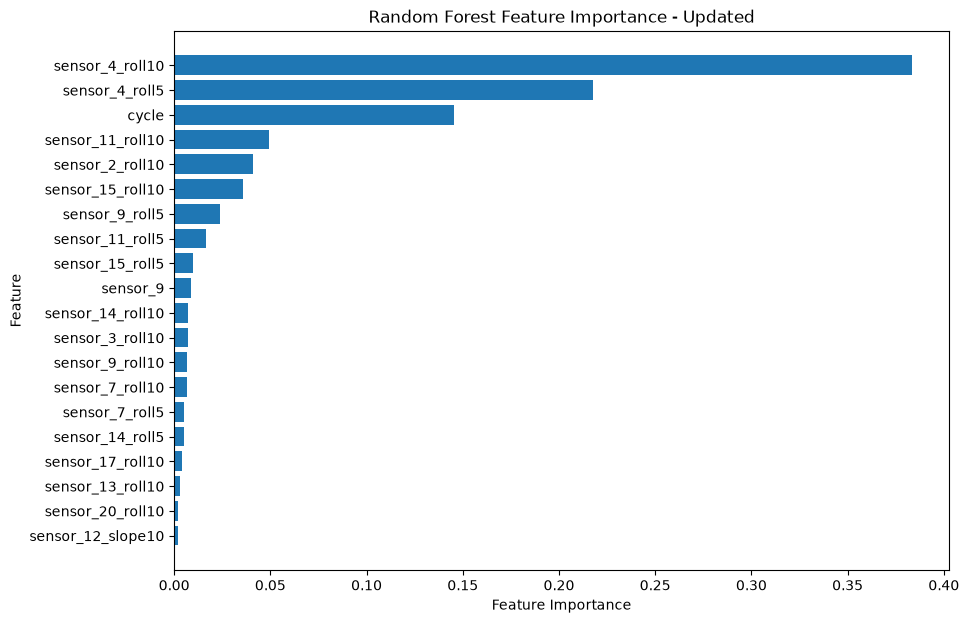

In [47]:
feature_importance_new = pd.DataFrame({
    "feature": features_slope10,
    "importance": rf_slope10.feature_importances_
})

feature_importance_new = feature_importance_new.sort_values(
    "importance",
    ascending=False
)
top_features = feature_importance_new.head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance - Updated")

plt.gca().invert_yaxis()

plt.show()

lets add standard deviation as a feature

In [49]:
std_sensors = [
    "sensor_4",
    "sensor_11",
    "sensor_2",
    "sensor_15",
    "sensor_9"
]

train_data = train_data.sort_values(
    ["engine_id", "cycle"]
).copy()

val_data = val_data.sort_values(
    ["engine_id", "cycle"]
).copy()

for sensor in std_sensors:

    train_data[f"{sensor}_std10"] = (
        train_data
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                window=10,
                min_periods=2
            ).std()
        )
        .fillna(0)
    )

    val_data[f"{sensor}_std10"] = (
        val_data
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                window=10,
                min_periods=2
            ).std()
        )
        .fillna(0)
    )

    features_std10 = (
    features_slope10
    + [
        f"{sensor}_std10"
        for sensor in std_sensors
    ]

    
)


X_train_std10 = train_data[features_std10]
X_val_std10 = val_data[features_std10]

y_train_std10 = train_data["RUL_capped"]
y_val_std10 = val_data["RUL_capped"]

train_pred_std10 = rf_std10.predict(
    X_train_std10
)

val_pred_std10 = rf_std10.predict(
    X_val_std10
)

NameError: name 'rf_std10' is not defined

In [ ]:
rf_std10 = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_std10.fit(
    X_train_std10,
    y_train_std10
)

train_mae_std10 = mean_absolute_error(
    y_train_std10,
    train_pred_std10
)

val_mae_std10 = mean_absolute_error(
    y_val_std10,
    val_pred_std10
)

train_rmse_std10 = root_mean_squared_error(
    y_train_std10,
    train_pred_std10
)

val_rmse_std10 = root_mean_squared_error(
    y_val_std10,
    val_pred_std10
)

print("Training MAE:", train_mae_std10)
print("Validation MAE:", val_mae_std10)

print("Training RMSE:", train_rmse_std10)
print("Validation RMSE:", val_rmse_std10)

Training MAE: 8.258400269601344
Validation MAE: 9.799189016098856
Training RMSE: 12.551152460608392
Validation RMSE: 14.714592856667533


SUMMARY: 
- the new current benchmark is val MAE = 9.8
- we were able to close the gap between training and val to fix overfitting issue
- now we could move on to neural network and choose the best model

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_nn = StandardScaler()

X_train_nn = scaler_nn.fit_transform(X_train_std10)
X_val_nn = scaler_nn.transform(X_val_std10)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

tf.random.set_seed(42)

In [ ]:
nn_model = Sequential([
    Input(shape=(X_train_nn.shape[1],)),
    Dense(128, activation="relu"),

    Dense(64, activation="relu"),

    Dense(32, activation="relu"),

    Dense(1)
])

In [ ]:
nn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,889 (23.00 KB)

 Trainable params: 5,889 (23.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = nn_model.fit(
    X_train_nn,
    y_train_std10,

    validation_data=(
        X_val_nn,
        y_val_std10
    ),

    epochs=100,
    batch_size=64,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2262.7178 - mae: 35.1890 - val_loss: 723.2525 - val_mae: 17.8101
Epoch 2/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 550.5507 - mae: 16.7501 - val_loss: 430.4044 - val_mae: 13.9678
Epoch 3/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 337.6992 - mae: 13.7409 - val_loss: 288.2523 - val_mae: 12.0606
Epoch 4/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 267.8142 - mae: 12.2371 - val_loss: 252.1216 - val_mae: 11.7731
Epoch 5/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 245.9946 - mae: 11.6536 - val_loss: 237.8288 - val_mae: 11.4755
Epoch 6/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 233.9401 - mae: 11.3370 - val_loss: 231.2207 - val_mae: 11.2763
Epoch 7/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 225.8063 - mae: 11.1061 - val_loss: 225.5711 - val_mae: 11.0404
Epoch 8/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 219.3111 - mae: 10.9117 - val_loss: 223.0915 - val_mae: 10.9244

In [ ]:
y_train_pred_nn = nn_model.predict(
    X_train_nn
).flatten()

y_val_pred_nn = nn_model.predict(
    X_val_nn
).flatten()

518/518 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
train_mae_nn = mean_absolute_error(
    y_train_std10,
    y_train_pred_nn
)

val_mae_nn = mean_absolute_error(
    y_val_std10,
    y_val_pred_nn
)

train_rmse_nn = root_mean_squared_error(
    y_train_std10,
    y_train_pred_nn
)

val_rmse_nn = root_mean_squared_error(
    y_val_std10,
    y_val_pred_nn
)

print("Training MAE:", train_mae_nn)
print("Validation MAE:", val_mae_nn)

print("Training RMSE:", train_rmse_nn)
print("Validation RMSE:", val_rmse_nn)

Training MAE: 9.976003646850586
Validation MAE: 10.646673202514648
Training RMSE: 13.692835807800293
Validation RMSE: 14.842864036560059


summary: 
- looks like not a high variance problem
- could be high bias or optimization

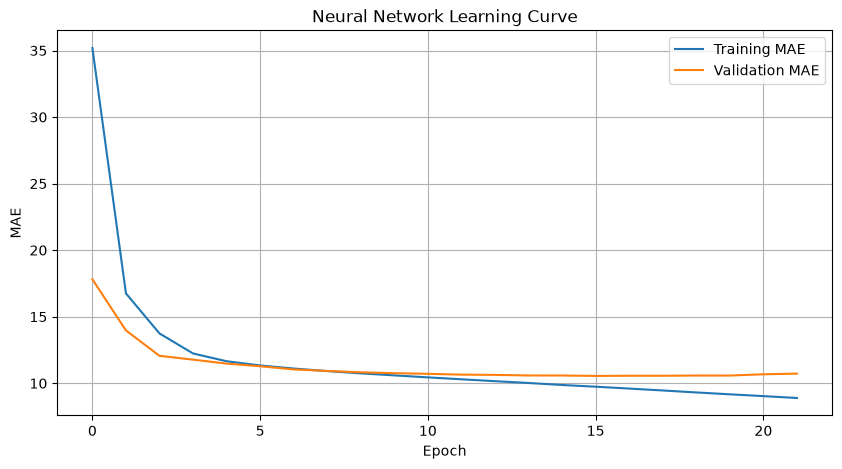

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Neural Network Learning Curve")
plt.legend()
plt.grid()

plt.show()

looks like neural networks aren't really a good model for this, lets stick with random forest

In [ ]:
results_rf = val_data.copy()

results_rf["predicted_RUL"] = rf_std10.predict(
    X_val_std10
)

results_rf["error"] = (
    results_rf["predicted_RUL"]
    - results_rf["RUL_capped"]
)

results_rf["absolute_error"] = abs(
    results_rf["error"]
)

In [ ]:
results_rf[
    [
        "engine_id",
        "cycle",
        "RUL_capped",
        "predicted_RUL",
        "error",
        "absolute_error"
    ]
].sort_values(
    "absolute_error",
    ascending=False
).head(20)

,engine_id,cycle,RUL_capped,predicted_RUL,error,absolute_error
17042,84,158,109,49.603673,-59.396327,59.396327
17041,84,157,110,52.925834,-57.074166,57.074166
17040,84,156,111,54.095185,-56.904815,56.904815
17005,84,121,125,69.015924,-55.984076,55.984076
17043,84,159,108,52.052484,-55.947516,55.947516
17004,84,120,125,69.990729,-55.009271,55.009271
17014,84,130,125,71.969597,-53.030403,53.030403
17003,84,119,125,71.995557,-53.004443,53.004443
17039,84,155,112,59.872871,-52.127129,52.127129
17037,84,153,114,62.108116,-51.891884,51.891884


In [ ]:
engine_errors = (
    results_rf
    .groupby("engine_id")["absolute_error"]
    .mean()
    .sort_values(ascending=False)
)

print(engine_errors)

engine_id
84    19.971132
45    18.681115
74    14.950072
77    14.889737
78    11.518521
31    11.426486
81    11.322989
46    11.184975
1      9.624929
13     8.472226
23     8.422068
11     8.224526
91     7.703486
40     6.864452
19     6.751625
54     5.866829
71     5.227941
32     5.227885
34     4.974999
5      4.943411
Name: absolute_error, dtype: float64


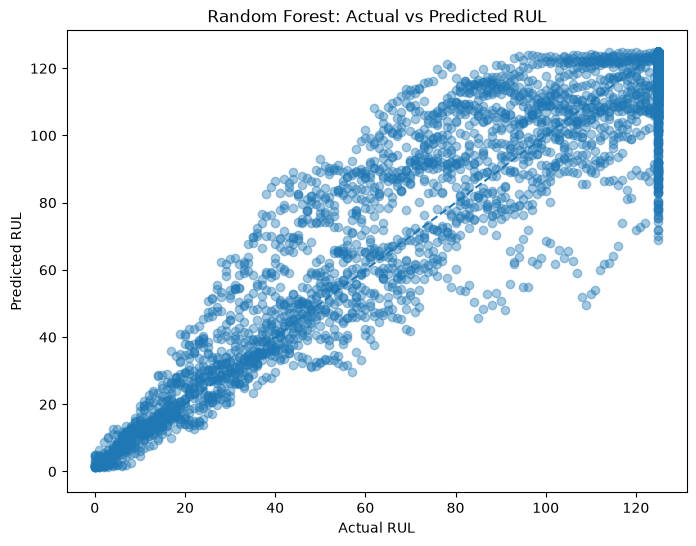

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    results_rf["RUL_capped"],
    results_rf["predicted_RUL"],
    alpha=0.4
)

plt.plot(
    [0, 125],
    [0, 125],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest: Actual vs Predicted RUL")

plt.show()

Worst: 84
Best: 5


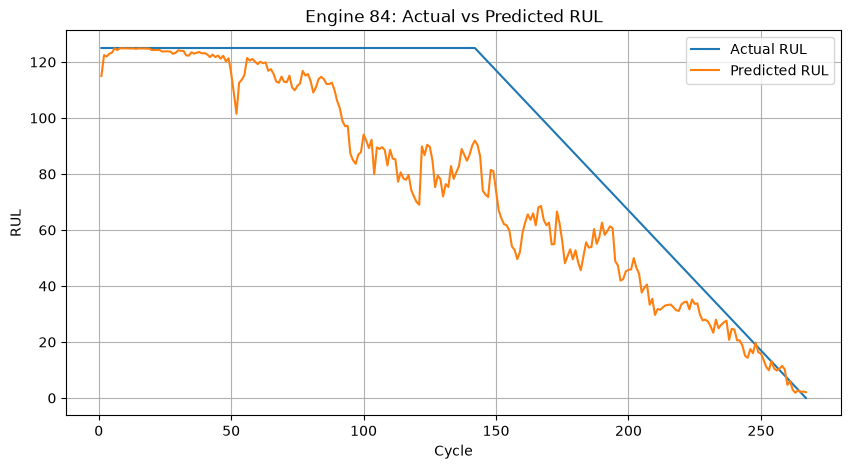

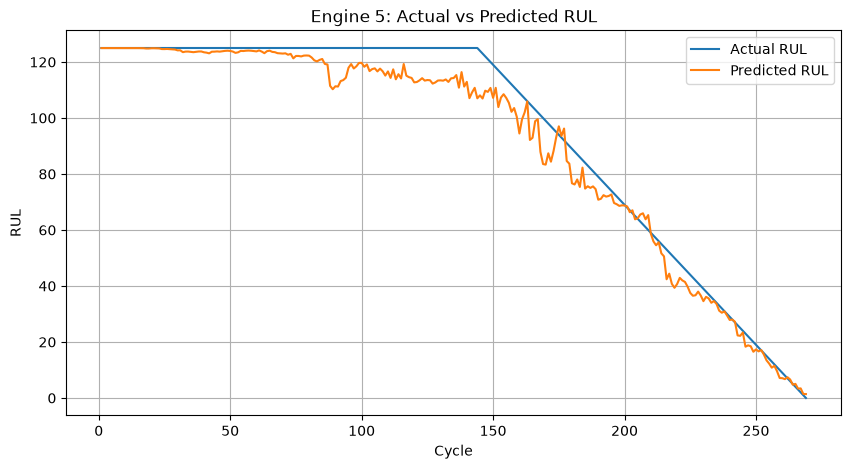

In [ ]:
worst_engine = engine_errors.index[0]
best_engine = engine_errors.index[-1]

print("Worst:", worst_engine)
print("Best:", best_engine)
def plot_engine_prediction(engine_id):

    engine = results_rf[
        results_rf["engine_id"] == engine_id
    ]

    plt.figure(figsize=(10, 5))

    plt.plot(
        engine["cycle"],
        engine["RUL_capped"],
        label="Actual RUL"
    )

    plt.plot(
        engine["cycle"],
        engine["predicted_RUL"],
        label="Predicted RUL"
    )

    plt.xlabel("Cycle")
    plt.ylabel("RUL")
    plt.title(
        f"Engine {engine_id}: Actual vs Predicted RUL"
    )

    plt.legend()
    plt.grid()

    plt.show()

plot_engine_prediction(worst_engine)
plot_engine_prediction(best_engine)

In [50]:
X_train_original = train_data[features_std10]
X_val_original = val_data[features_std10]

y_train_original = train_data["RUL"]
y_val_original = val_data["RUL"]

rf_original = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_original.fit(
    X_train_original,
    y_train_original
)
y_train_pred_original = rf_original.predict(
    X_train_original
)

y_val_pred_original = rf_original.predict(
    X_val_original
)

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

train_mae = mean_absolute_error(
    y_train_original,
    y_train_pred_original
)

val_mae = mean_absolute_error(
    y_val_original,
    y_val_pred_original
)

train_rmse = root_mean_squared_error(
    y_train_original,
    y_train_pred_original
)

val_rmse = root_mean_squared_error(
    y_val_original,
    y_val_pred_original
)

train_r2 = r2_score(
    y_train_original,
    y_train_pred_original
)

val_r2 = r2_score(
    y_val_original,
    y_val_pred_original
)

print("Training MAE:", train_mae)
print("Validation MAE:", val_mae)

print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

print("Training R²:", train_r2)
print("Validation R²:", val_r2)

Training MAE: 17.883168957140164
Validation MAE: 23.729511301993682
Training RMSE: 25.220962163307586
Validation RMSE: 32.25969390529101
Training R²: 0.8688302913414201
Validation R²: 0.7585507779169165


In [51]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 3.7 MB/s eta 0:00:13
   - -------------------------------------- 1.3/48.9 MB 2.9 MB/s eta 0:00:17
   - -------------------------------------- 2.4/48.9 MB 3.8 MB/s eta 0:00:13
   -- ------------------------------------- 2.9/48.9 MB 3.7 MB/s eta 0:00:13
   -- ------------------------------------- 3.7/48.9 MB 3.7 MB/s eta 0:00:13
   --- ------------------------------------ 4.5/48.9 MB 3.7 MB/s eta 0:00:13
   ---- ----------------------------------- 5.2/48.9 MB 3.7 MB/s eta 0:00:12
   ---- ----------------------------------- 6.0/48.9 MB 3.7 MB/s eta 0:00:12
   ----- ---------------------------------- 6.8/48.9 MB 3.7 MB/s eta 0:00:12
   ------ --------------------------------- 7.6/48.9 MB 3.7 MB/s eta 0:00:12
   ------ --


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
import xgboost as xgb

print(xgb.__version__)

3.4.1


In [53]:
X_train_xgb = train_data[features_std10]
X_val_xgb = val_data[features_std10]

y_train_xgb = train_data["RUL"]
y_val_xgb = val_data["RUL"]

In [54]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,

    subsample=0.8,
    colsample_bytree=0.8,

    objective="reg:squarederror",
    eval_metric="mae",

    early_stopping_rounds=30,

    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

In [55]:
xgb_model.fit(
    X_train_xgb,
    y_train_xgb,

    eval_set=[
        (X_val_xgb, y_val_xgb)
    ],

    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'mae'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [56]:
y_train_pred_xgb = xgb_model.predict(
    X_train_xgb
)

y_val_pred_xgb = xgb_model.predict(
    X_val_xgb
)

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

train_mae_xgb = mean_absolute_error(
    y_train_xgb,
    y_train_pred_xgb
)

val_mae_xgb = mean_absolute_error(
    y_val_xgb,
    y_val_pred_xgb
)

train_rmse_xgb = root_mean_squared_error(
    y_train_xgb,
    y_train_pred_xgb
)

val_rmse_xgb = root_mean_squared_error(
    y_val_xgb,
    y_val_pred_xgb
)

train_r2_xgb = r2_score(
    y_train_xgb,
    y_train_pred_xgb
)

val_r2_xgb = r2_score(
    y_val_xgb,
    y_val_pred_xgb
)

print("Training MAE:", train_mae_xgb)
print("Validation MAE:", val_mae_xgb)

print("Training RMSE:", train_rmse_xgb)
print("Validation RMSE:", val_rmse_xgb)

print("Training R²:", train_r2_xgb)
print("Validation R²:", val_r2_xgb)

Training MAE: 21.75705337524414
Validation MAE: 23.767822265625
Training RMSE: 30.604394912719727
Validation RMSE: 31.674989700317383
Training R²: 0.8068574666976929
Validation R²: 0.7672239542007446


In [57]:
depths = [3, 5, 7, 9]
for depth in depths:

    model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=depth,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        eval_metric="mae",
        early_stopping_rounds=30,
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )

    model.fit(
        X_train_xgb,
        y_train_xgb,
        eval_set=[(X_val_xgb, y_val_xgb)],
        verbose=False
    )

    train_pred = model.predict(X_train_xgb)
    val_pred = model.predict(X_val_xgb)

    print("Depth:", depth)
    print(
        "Train MAE:",
        mean_absolute_error(y_train_xgb, train_pred)
    )
    print(
        "Val MAE:",
        mean_absolute_error(y_val_xgb, val_pred)
    )
    print(
        "Val RMSE:",
        root_mean_squared_error(y_val_xgb, val_pred)
    )
    print(
        "Best iteration:",
        model.best_iteration
    )
    print("--------------------")

Depth: 3
Train MAE: 24.822330474853516
Val MAE: 22.87241554260254
Val RMSE: 30.159217834472656
Best iteration: 83
--------------------
Depth: 5
Train MAE: 21.75705337524414
Val MAE: 23.767822265625
Val RMSE: 31.674989700317383
Best iteration: 67
--------------------
Depth: 7
Train MAE: 15.924264907836914
Val MAE: 24.008499145507812
Val RMSE: 32.22848129272461
Best iteration: 69
--------------------
Depth: 9
Train MAE: 8.751986503601074
Val MAE: 23.949190139770508
Val RMSE: 32.600608825683594
Best iteration: 82
--------------------


In [58]:
learning_rates = [0.01, 0.03, 0.05, 0.1]

for lr in learning_rates:

    model = xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=lr,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        eval_metric="mae",
        early_stopping_rounds=30,
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )

    model.fit(
        X_train_xgb,
        y_train_xgb,
        eval_set=[(X_val_xgb, y_val_xgb)],
        verbose=False
    )

    train_pred = model.predict(X_train_xgb)
    val_pred = model.predict(X_val_xgb)

    print("Learning rate:", lr)
    print(
        "Train MAE:",
        mean_absolute_error(y_train_xgb, train_pred)
    )
    print(
        "Val MAE:",
        mean_absolute_error(y_val_xgb, val_pred)
    )
    print(
        "Val RMSE:",
        root_mean_squared_error(y_val_xgb, val_pred)
    )
    print(
        "Best iteration:",
        model.best_iteration
    )
    print("--------------------")

Learning rate: 0.01
Train MAE: 24.539762496948242
Val MAE: 22.873207092285156
Val RMSE: 30.292299270629883
Best iteration: 477
--------------------
Learning rate: 0.03
Train MAE: 24.612606048583984
Val MAE: 22.872953414916992
Val RMSE: 30.20041847229004
Best iteration: 153
--------------------
Learning rate: 0.05
Train MAE: 24.822330474853516
Val MAE: 22.87241554260254
Val RMSE: 30.159217834472656
Best iteration: 83
--------------------
Learning rate: 0.1
Train MAE: 24.621931076049805
Val MAE: 23.017175674438477
Val RMSE: 30.5521297454834
Best iteration: 45
--------------------


In [59]:
subsample_values = [0.6, 0.8, 1.0]
for sub in subsample_values:

    model = xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=3,
        subsample=sub,
        colsample_bytree=0.8,

        objective="reg:squarederror",
        eval_metric="mae",
        early_stopping_rounds=30,

        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )

    model.fit(
        X_train_xgb,
        y_train_xgb,
        eval_set=[(X_val_xgb, y_val_xgb)],
        verbose=False
    )

    train_pred = model.predict(X_train_xgb)
    val_pred = model.predict(X_val_xgb)

    print("Subsample:", sub)

    print(
        "Train MAE:",
        mean_absolute_error(
            y_train_xgb,
            train_pred
        )
    )

    print(
        "Val MAE:",
        mean_absolute_error(
            y_val_xgb,
            val_pred
        )
    )

    print(
        "Val RMSE:",
        root_mean_squared_error(
            y_val_xgb,
            val_pred
        )
    )

    print(
        "Best iteration:",
        model.best_iteration
    )

    print("--------------------")

Subsample: 0.6
Train MAE: 24.86969757080078
Val MAE: 22.76285171508789
Val RMSE: 30.024261474609375
Best iteration: 85
--------------------
Subsample: 0.8
Train MAE: 24.822330474853516
Val MAE: 22.87241554260254
Val RMSE: 30.159217834472656
Best iteration: 83
--------------------
Subsample: 1.0
Train MAE: 24.53587532043457
Val MAE: 22.83411979675293
Val RMSE: 30.271160125732422
Best iteration: 98
--------------------


In [60]:
colsample_values = [0.5, 0.7, 0.8, 1.0]

for col in colsample_values:

    model = xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=3,

        subsample=0.6,
        colsample_bytree=col,

        objective="reg:squarederror",
        eval_metric="mae",
        early_stopping_rounds=30,

        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )

    model.fit(
        X_train_xgb,
        y_train_xgb,
        eval_set=[(X_val_xgb, y_val_xgb)],
        verbose=False
    )

    train_pred = model.predict(X_train_xgb)
    val_pred = model.predict(X_val_xgb)

    print("Column sample:", col)

    print(
        "Train MAE:",
        mean_absolute_error(
            y_train_xgb,
            train_pred
        )
    )

    print(
        "Val MAE:",
        mean_absolute_error(
            y_val_xgb,
            val_pred
        )
    )

    print(
        "Val RMSE:",
        root_mean_squared_error(
            y_val_xgb,
            val_pred
        )
    )

    print(
        "Best iteration:",
        model.best_iteration
    )

    print("--------------------")

Column sample: 0.5
Train MAE: 24.550357818603516
Val MAE: 22.293977737426758
Val RMSE: 29.410429000854492
Best iteration: 102
--------------------
Column sample: 0.7
Train MAE: 24.558080673217773
Val MAE: 22.590356826782227
Val RMSE: 29.837831497192383
Best iteration: 97
--------------------
Column sample: 0.8
Train MAE: 24.86969757080078
Val MAE: 22.76285171508789
Val RMSE: 30.024261474609375
Best iteration: 85
--------------------
Column sample: 1.0
Train MAE: 24.82270050048828
Val MAE: 22.94588279724121
Val RMSE: 30.13007354736328
Best iteration: 83
--------------------


In [61]:
colsample_values = [0.3, 0.4, 0.5, 0.6]

for col in colsample_values:

    model = xgb.XGBRegressor(
        n_estimators=2000,

        learning_rate=0.05,
        max_depth=3,
        subsample=0.6,
        colsample_bytree=col,

        objective="reg:squarederror",
        eval_metric="mae",
        early_stopping_rounds=30,

        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )

    model.fit(
        X_train_xgb,
        y_train_xgb,
        eval_set=[
            (X_val_xgb, y_val_xgb)
        ],
        verbose=False
    )

    train_pred = model.predict(X_train_xgb)
    val_pred = model.predict(X_val_xgb)

    train_mae = mean_absolute_error(
        y_train_xgb,
        train_pred
    )

    val_mae = mean_absolute_error(
        y_val_xgb,
        val_pred
    )

    val_rmse = root_mean_squared_error(
        y_val_xgb,
        val_pred
    )

    val_r2 = r2_score(
        y_val_xgb,
        val_pred
    )

    print("Column sample:", col)
    print("Train MAE:", train_mae)
    print("Val MAE:", val_mae)
    print("Val RMSE:", val_rmse)
    print("Val R²:", val_r2)
    print("Best iteration:", model.best_iteration)
    print("--------------------")

Column sample: 0.3
Train MAE: 24.754941940307617
Val MAE: 21.920791625976562
Val RMSE: 28.873157501220703
Val R²: 0.8065833449363708
Best iteration: 125
--------------------
Column sample: 0.4
Train MAE: 24.37379264831543
Val MAE: 22.06381607055664
Val RMSE: 29.07869529724121
Val R²: 0.8038198351860046
Best iteration: 125
--------------------
Column sample: 0.5
Train MAE: 24.550357818603516
Val MAE: 22.293977737426758
Val RMSE: 29.410429000854492
Val R²: 0.7993181943893433
Best iteration: 102
--------------------
Column sample: 0.6
Train MAE: 24.566171646118164
Val MAE: 22.35939598083496
Val RMSE: 29.530948638916016
Val R²: 0.7976701259613037
Best iteration: 97
--------------------


In [62]:
final_xgb = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.6,
    colsample_bytree= 0.4,

    objective="reg:squarederror",
    eval_metric="mae",
    early_stopping_rounds=30,

    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

final_xgb.fit(
    X_train_xgb,
    y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False
)

train_pred_xgb = final_xgb.predict(X_train_xgb)
val_pred_xgb = final_xgb.predict(X_val_xgb)

train_mae = mean_absolute_error(
    y_train_xgb,
    train_pred_xgb
)

val_mae = mean_absolute_error(
    y_val_xgb,
    val_pred_xgb
)

train_rmse = root_mean_squared_error(
    y_train_xgb,
    train_pred_xgb
)

val_rmse = root_mean_squared_error(
    y_val_xgb,
    val_pred_xgb
)

val_r2 = r2_score(
    y_val_xgb,
    val_pred_xgb
)

print("Training MAE:", train_mae)
print("Validation MAE:", val_mae)

print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

print("Validation R²:", val_r2)

print("Best iteration:", final_xgb.best_iteration)

Training MAE: 24.37379264831543
Validation MAE: 22.06381607055664
Training RMSE: 34.16523361206055
Validation RMSE: 29.07869529724121
Validation R²: 0.8038198351860046
Best iteration: 125


In [63]:
xgb_results = val_data.copy()

xgb_results["predicted_RUL"] = val_pred_xgb

xgb_results["error"] = (
    xgb_results["predicted_RUL"]
    - xgb_results["RUL"]
)

xgb_results["absolute_error"] = abs(
    xgb_results["error"]
)

xgb_results[
    [
        "engine_id",
        "cycle",
        "RUL",
        "predicted_RUL",
        "error",
        "absolute_error"
    ]
].sort_values(
    "absolute_error",
    ascending=False
).head(20)

xgb_engine_errors = (
    xgb_results
    .groupby("engine_id")["absolute_error"]
    .mean()
    .sort_values(ascending=False)
)

print(xgb_engine_errors)

engine_id
84    44.824855
45    38.660296
74    31.743876
1     31.190070
46    30.161645
77    28.597104
91    26.106619
5     23.970232
31    23.850118
54    22.882970
13    21.004458
23    19.255309
81    18.927346
19    18.659598
78    15.522163
11    11.536798
40    11.054798
71     8.795001
32     7.198305
34     5.739660
Name: absolute_error, dtype: float64


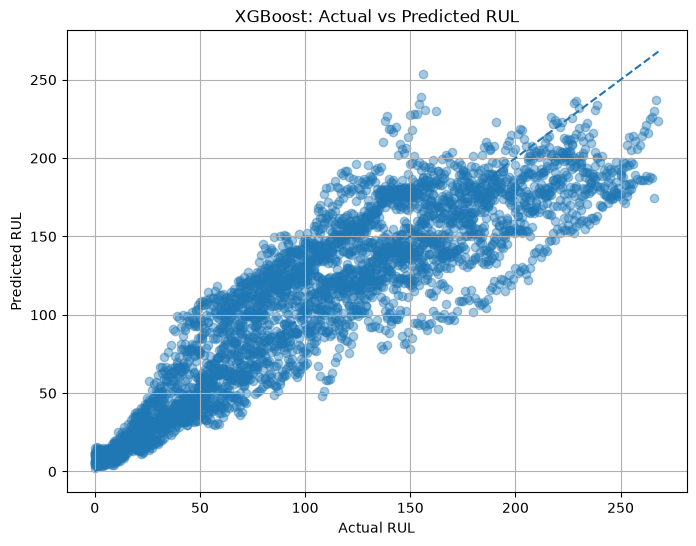

In [64]:
plt.figure(figsize=(8, 6))

plt.scatter(
    xgb_results["RUL"],
    xgb_results["predicted_RUL"],
    alpha=0.4
)

minimum = min(
    xgb_results["RUL"].min(),
    xgb_results["predicted_RUL"].min()
)

maximum = max(
    xgb_results["RUL"].max(),
    xgb_results["predicted_RUL"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost: Actual vs Predicted RUL")

plt.grid()
plt.show()

In [66]:
from sklearn.model_selection import train_test_split
full_data = pd.concat(
    [train_data, val_data],
    ignore_index=True
)

full_data = (
    full_data
    .sort_values(["engine_id", "cycle"])
    .reset_index(drop=True)
)

print("Engines:", full_data["engine_id"].nunique())
engine_ids = full_data["engine_id"].unique()

# 60% train, 40% temporary
train_engines, temp_engines = train_test_split(
    engine_ids,
    test_size=0.40,
    random_state=42
)

# Split remaining 40% equally -> 20% validation + 20% test
val_engines, test_engines = train_test_split(
    temp_engines,
    test_size=0.50,
    random_state=42
)

Engines: 100


In [67]:
train_60 = full_data[
    full_data["engine_id"].isin(train_engines)
].copy()

val_20 = full_data[
    full_data["engine_id"].isin(val_engines)
].copy()

test_20 = full_data[
    full_data["engine_id"].isin(test_engines)
].copy()

In [68]:
X_train_60 = train_60[features_std10]
y_train_60 = train_60["RUL"]

X_val_20 = val_20[features_std10]
y_val_20 = val_20["RUL"]

X_test_20 = test_20[features_std10]
y_test_20 = test_20["RUL"]

In [69]:
final_xgb_60 = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.6,
    colsample_bytree=0.4,  # replace if another value won

    objective="reg:squarederror",
    eval_metric="mae",
    early_stopping_rounds=30,

    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

final_xgb_60.fit(
    X_train_60,
    y_train_60,
    eval_set=[(X_val_20, y_val_20)],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.4
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'mae'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [70]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

test_pred = final_xgb_60.predict(X_test_20)

test_mae = mean_absolute_error(
    y_test_20,
    test_pred
)

test_rmse = root_mean_squared_error(
    y_test_20,
    test_pred
)

test_r2 = r2_score(
    y_test_20,
    test_pred
)

print("TEST MAE:", test_mae)
print("TEST RMSE:", test_rmse)
print("TEST R²:", test_r2)
print("Best iteration:", final_xgb_60.best_iteration)

TEST MAE: 27.316621780395508
TEST RMSE: 35.83025360107422
TEST R²: 0.7064114809036255
Best iteration: 62


In [75]:
X_train_60 = train_60[features_std10]
X_val_20 = val_20[features_std10]
X_test_20 = test_20[features_std10]

y_train_60 = train_60["RUL_capped"]
y_val_20 = val_20["RUL_capped"]
y_test_20 = test_20["RUL_capped"]

final_xgb_capped = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.6,
    colsample_bytree=0.4,   # use whichever value won your tuning

    objective="reg:squarederror",
    eval_metric="mae",
    early_stopping_rounds=30,

    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

final_xgb_capped.fit(
    X_train_60,
    y_train_60,
    eval_set=[(X_val_20, y_val_20)],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.4
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'mae'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [76]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

test_pred_capped = final_xgb_capped.predict(X_test_20)

test_mae_capped = mean_absolute_error(
    y_test_20,
    test_pred_capped
)

test_rmse_capped = root_mean_squared_error(
    y_test_20,
    test_pred_capped
)

test_r2_capped = r2_score(
    y_test_20,
    test_pred_capped
)

print("CAPPED TEST MAE:", test_mae_capped)
print("CAPPED TEST RMSE:", test_rmse_capped)
print("CAPPED TEST R²:", test_r2_capped)
print(
    "Best iteration:",
    final_xgb_capped.best_iteration
)

CAPPED TEST MAE: 11.849985122680664
CAPPED TEST RMSE: 16.676128387451172
CAPPED TEST R²: 0.8398720622062683
Best iteration: 253


In [77]:
from pathlib import Path

model_path = Path("../models/xgboost_capped.json")

model_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

final_xgb_capped.save_model(model_path)

print("Model saved to:", model_path)

Model saved to: ..\models\xgboost_capped.json
